In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("E:/Projects/Smart-Logistics-System/data/processed/dataset_with_risk_levels.csv")
df.head()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Precipitation(mm),Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,...,Asset_ID_Truck_3,Asset_ID_Truck_4,Asset_ID_Truck_5,Asset_ID_Truck_6,Asset_ID_Truck_7,Asset_ID_Truck_8,Asset_ID_Truck_9,delay_probability,ml_risk_level,final_risk_level
0,-65.7383,11.2497,390,27.0,67.8,10.023475,38,320,4,60.1,...,0,0,0,0,1,0,0,0.339254,Low,Low
1,22.2748,-131.7086,491,22.5,54.3,21.397599,16,439,7,80.9,...,0,0,0,1,0,0,0,0.870765,Critical,Critical
2,54.9232,79.5455,190,25.2,62.2,14.520535,34,355,3,99.2,...,0,0,0,0,0,0,0,0.452376,Medium,High
3,42.3900,-1.4788,330,25.4,52.3,2.613761,37,227,5,97.4,...,0,0,0,0,0,0,1,0.842010,High,High
4,-65.8477,47.9468,480,20.5,57.2,35.412586,56,197,6,71.6,...,0,0,0,0,1,0,0,0.471364,Medium,Medium


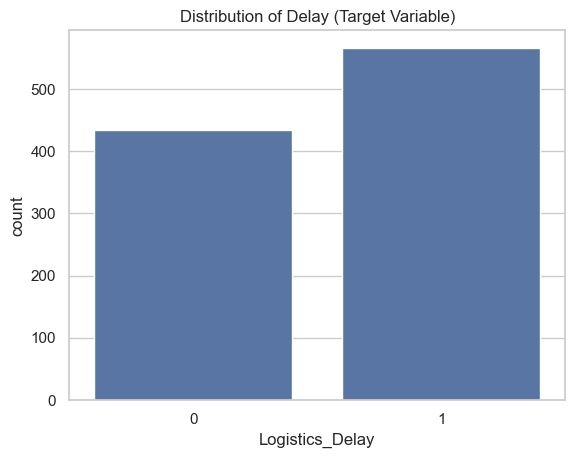

In [5]:
sns.countplot(x="Logistics_Delay", data=df)
plt.title("Distribution of Delay (Target Variable)")
plt.show()

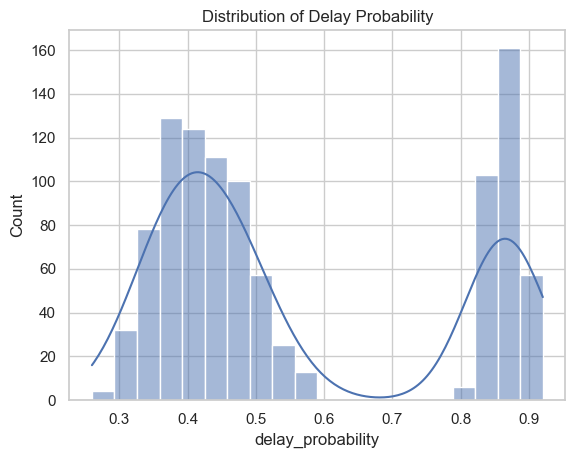

In [6]:
sns.histplot(df["delay_probability"], bins=20, kde=True)
plt.title("Distribution of Delay Probability")
plt.show()

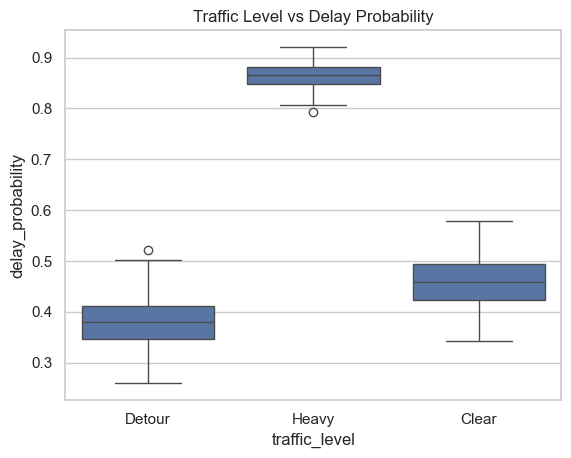

In [7]:
def get_traffic_level(row):
    if row["Traffic_Status_Heavy"] == 1:
        return "Heavy"
    elif row["Traffic_Status_Detour"] == 1:
        return "Detour"
    else:
        return "Clear"

df["traffic_level"] = df.apply(get_traffic_level, axis=1)

sns.boxplot(x="traffic_level", y="delay_probability", data=df)
plt.title("Traffic Level vs Delay Probability")
plt.show()

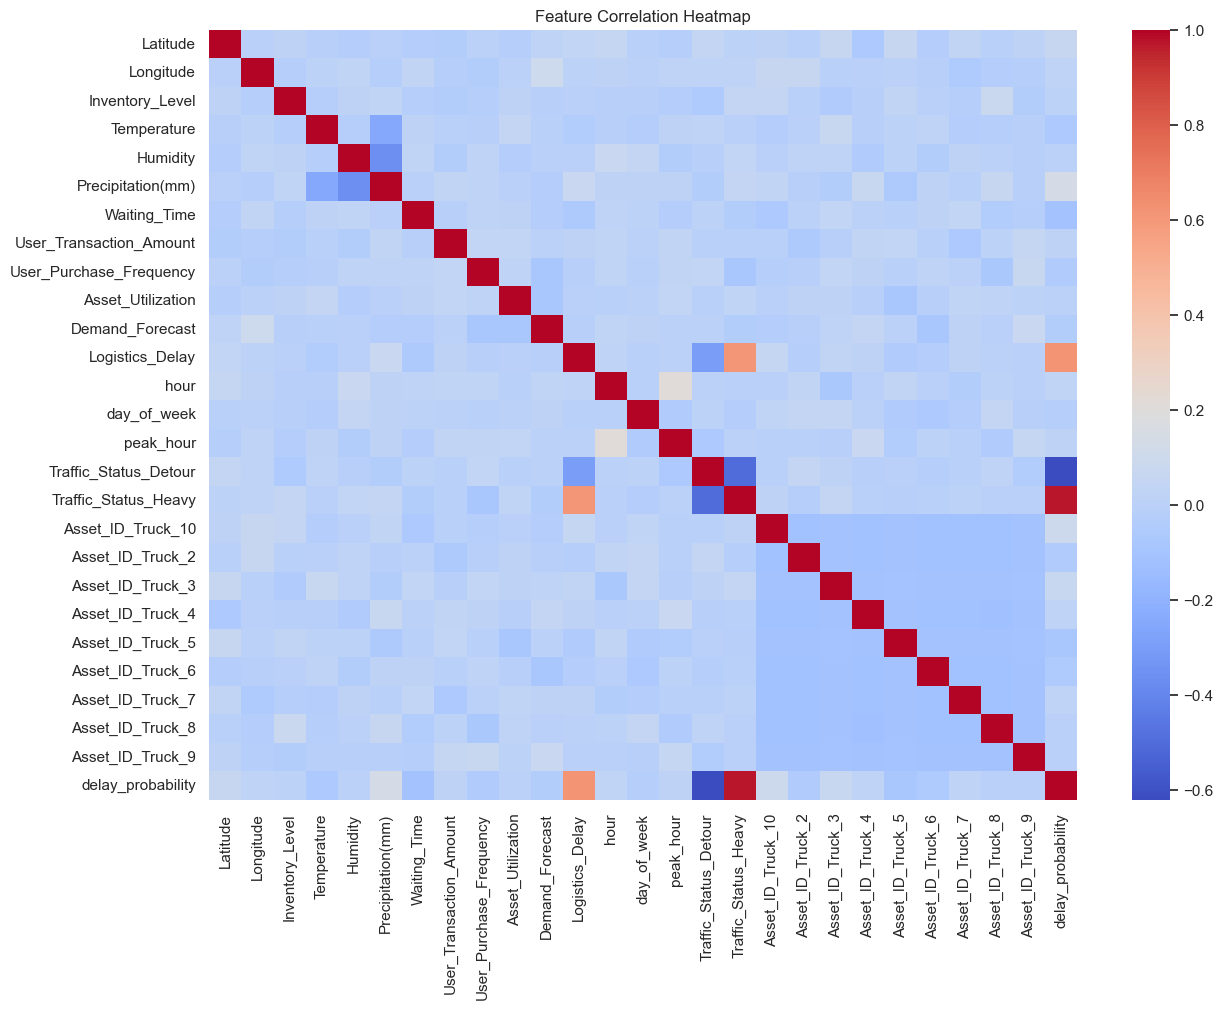

In [8]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
corr = df.corr(numeric_only=True)["delay_probability"].sort_values(ascending=False)
print(corr)

delay_probability          1.000000
Traffic_Status_Heavy       0.969457
Logistics_Delay            0.614589
Precipitation(mm)          0.133173
Asset_ID_Truck_10          0.094333
Asset_ID_Truck_3           0.066247
Latitude                   0.062887
hour                       0.028821
Asset_ID_Truck_7           0.023856
Longitude                  0.021815
Asset_ID_Truck_4           0.021288
User_Transaction_Amount    0.018007
peak_hour                  0.016375
Inventory_Level            0.011340
Asset_Utilization          0.005367
Humidity                   0.005233
Asset_ID_Truck_8          -0.001391
Asset_ID_Truck_9          -0.002410
day_of_week               -0.019751
Demand_Forecast           -0.036607
Asset_ID_Truck_2          -0.048644
User_Purchase_Frequency   -0.049888
Asset_ID_Truck_6          -0.051311
Temperature               -0.068397
Asset_ID_Truck_5          -0.079854
Waiting_Time              -0.108502
Traffic_Status_Detour     -0.620152
Name: delay_probability, dty